In [7]:
# Import required libraries
import os
import random
import numpy as np
import pandas as pd
from datetime import datetime
import pickle
import warnings
warnings.filterwarnings('ignore')

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Add SMOTE for handling imbalanced classes
from imblearn.over_sampling import SMOTE

# TensorFlow imports
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


In [8]:

# Also need these imports for the complete class
from scipy.stats import entropy
from sklearn.utils.class_weight import compute_class_weight


In [9]:
import pandas as pd

# Load the CSV
df = pd.read_csv('../newdataset_with_mitm.csv', low_memory=False)

# Convert frame.time to datetime if it's not already
df['frame.time'] = pd.to_datetime(df['frame.time'], errors='coerce')

# Sort by frame.time in ascending order
df_sorted = df.sort_values('frame.time', ascending=True)

# Remove temporary columns if they exist
temp_columns = ['tbin', 'test_tbin', 'tbin_optimal', 'artificial_time']
df_sorted = df_sorted.drop(columns=[col for col in temp_columns if col in df_sorted.columns])

# Save to new CSV file
df_sorted.to_csv('../sorted_dataset_mitm.csv', index=False)

print("✅ Sorted dataset saved to ../sorted_dataset.csv")
print(f"First timestamp: {df_sorted['frame.time'].min()}")
print(f"Last timestamp: {df_sorted['frame.time'].max()}")
print(f"Total rows: {len(df_sorted)}")
print(f"Columns: {list(df_sorted.columns)}")

✅ Sorted dataset saved to ../sorted_dataset.csv
First timestamp: 2021-01-01 01:22:48.001177
Last timestamp: 2021-11-27 23:40:47.816351
Total rows: 478554
Columns: ['frame.time', 'ip.src_host', 'ip.dst_host', 'tcp.srcport', 'tcp.dstport', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.connection.rst', 'tcp.connection.fin', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.payload', 'tcp.checksum', 'icmp.checksum', 'icmp.seq_le', 'http.request.method', 'http.request.full_uri', 'http.content_length', 'http.response', 'http.referer', 'dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'Attack_type']


In [10]:
import pandas as pd

# treat missing Attack_type as 'Normal' and map Normal -> 0, others -> 1

df_sorted['attack_label'] = df_sorted['Attack_type'].fillna('Normal').apply(lambda v: 0 if str(v).strip().lower() == 'normal' else 1)
df_sorted_binary = df_sorted
df_sorted_binary.to_csv('../sorted_dataset_binary.csv', index=False)

print("✓ Added attack_label to ../sorted_dataset_binary.csv")


✓ Added attack_label to ../sorted_dataset_binary.csv


In [13]:
df['frame.time'] = pd.to_datetime(df['frame.time'], errors='coerce')
print("Earliest timestamp:", df['frame.time'].min())
print("Latest timestamp:", df['frame.time'].max())
print("Duration:", df['frame.time'].max() - df['frame.time'].min())


Earliest timestamp: 2021-01-01 01:22:48.001177
Latest timestamp: 2021-11-27 23:40:47.816351
Duration: 330 days 22:17:59.815174


In [15]:
import pandas as pd
import numpy as np
from scipy.stats import entropy

# ===================== CONFIG =====================
DATA_PATH = "/Users/safwanahmed/Desktop/preprocessing/sorted_dataset_binary.csv"
OUTPUT_PATH = "/Users/safwanahmed/Desktop/preprocessing/engineered_features.csv"
WINDOW_SIZE_SEC = 5  # seconds
STEP_SIZE_SEC = 1    # seconds
# ==================================================

print("📂 Loading dataset...")
df = pd.read_csv(DATA_PATH, parse_dates=['frame.time'])
print(f"✅ Loaded {len(df):,} packets")

# --- Convert timestamps ---
df = df.sort_values('frame.time')
df['timestamp'] = df['frame.time'].astype('int64') / 1e9

start_time = df['timestamp'].min()
end_time = df['timestamp'].max()
duration = df['frame.time'].max() - df['frame.time'].min()
print("🕒 Total duration:", duration)

# --- Define helper functions ---
def shannon_entropy(series):
    counts = series.value_counts()
    return entropy(counts, base=2) if len(counts) > 0 else 0

# --- Generate only windows where data exists ---
# Instead of looping across full time span, jump to next actual packet time
packet_times = df['timestamp'].values
features = []
i = 0
n = len(packet_times)

print("⚙️ Generating window features...")
while i < n:
    window_start = packet_times[i]
    window_end = window_start + WINDOW_SIZE_SEC

    # Select all packets in the current window
    mask = (df['timestamp'] >= window_start) & (df['timestamp'] < window_end)
    group = df.loc[mask]

    # Skip if window empty (should rarely happen)
    if group.empty:
        i += 1
        continue

    # Compute aggregated window features
    row = {
        'window_start': pd.Timestamp(window_start, unit='s'),
        'packet_count': len(group),
        'syn_count': group['tcp.connection.syn'].sum(),
        'synack_count': group['tcp.connection.synack'].sum(),
        'rst_count': group['tcp.connection.rst'].sum(),
        'fin_count': group['tcp.connection.fin'].sum(),
        'tcp_len_total': group['tcp.len'].sum(),
        'tcp_len_avg': group['tcp.len'].mean(),
        'unique_src_ips': group['ip.src_host'].nunique(),
        'unique_dst_ips': group['ip.dst_host'].nunique(),
        'src_entropy': shannon_entropy(group['ip.src_host']),
        'dst_entropy': shannon_entropy(group['ip.dst_host']),
        'src_port_entropy': shannon_entropy(group['tcp.srcport']),
        'dst_port_entropy': shannon_entropy(group['tcp.dstport']),
        'syn_ratio': group['tcp.connection.syn'].sum() / (len(group) + 1e-6),
        'rst_ratio': group['tcp.connection.rst'].sum() / (len(group) + 1e-6),
        'http_get_count': (group['http.request.method'] == 'GET').sum(),
        'http_post_count': (group['http.request.method'] == 'POST').sum(),
        'http_uri_entropy': shannon_entropy(group['http.request.full_uri'].dropna()),
        'http_avg_content_length': group['http.content_length']
            .dropna().astype(float).mean() if 'http.content_length' in group else 0,
        'icmp_count': group['icmp.checksum'].notnull().sum(),
        'dns_query_count': group['dns.qry.name'].notnull().sum(),
        'dns_query_entropy': shannon_entropy(group['dns.qry.name'].dropna()),
        'avg_payload_len': group['tcp.payload']
            .dropna().astype(str).apply(len).mean() if 'tcp.payload' in group else 0,
        'label': int(group['Attack_label'].max()) if 'Attack_label' in group else 0
    }
    features.append(row)

    # Jump forward by step size (not every single second)
    next_time = window_start + STEP_SIZE_SEC
    # Skip all packets that are before next_time
    while i < n and packet_times[i] < next_time:
        i += 1

# --- Build and save features ---
feature_df = pd.DataFrame(features)
feature_df.to_csv(OUTPUT_PATH, index=False)
print(f"✅ Feature extraction complete! {len(feature_df):,} windows saved to {OUTPUT_PATH}")

# --- Summary ---
print("\n📊 Feature Summary:")
print(feature_df.describe(include='all').transpose().head(15))


📂 Loading dataset...
✅ Loaded 478,554 packets
🕒 Total duration: 330 days 22:17:59.815174
⚙️ Generating window features...
✅ Feature extraction complete! 35,811 windows saved to /Users/safwanahmed/Desktop/preprocessing/engineered_features.csv

📊 Feature Summary:
                    count                           mean  \
window_start        35811  2021-01-04 08:31:17.992917248   
packet_count      35811.0                      62.806931   
syn_count         35811.0                       8.664321   
synack_count      35811.0                       1.736338   
rst_count         35811.0                       7.388819   
fin_count         35811.0                       3.335539   
tcp_len_total     35811.0                    5280.537656   
tcp_len_avg       35811.0                      55.064968   
unique_src_ips    35811.0                       19.58496   
unique_dst_ips    35811.0                       7.922203   
src_entropy       35811.0                       1.225554   
dst_entropy       

In [16]:
import pandas as pd

sample = pd.read_csv("engineered_features.csv")
print((sample["label"] == 1).sum())
print((sample["label"] == 0).sum())



11216
31284


Epoch 1/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8328 - loss: 0.3791 - val_accuracy: 0.9227 - val_loss: 0.3314
Epoch 2/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9763 - loss: 0.0946 - val_accuracy: 0.9967 - val_loss: 0.0994
Epoch 3/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9860 - loss: 0.0647 - val_accuracy: 0.9996 - val_loss: 0.0361
Epoch 4/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9875 - loss: 0.0592 - val_accuracy: 0.9999 - val_loss: 0.0177
Epoch 5/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9889 - loss: 0.0575 - val_accuracy: 0.9999 - val_loss: 0.0115
Epoch 6/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9905 - loss: 0.0531 - val_accuracy: 0.9999 - val_loss: 0.0095
Epoch 7/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9913 - loss: 0.0571 - val_accuracy: 0.9999 - val_loss: 0.0074
Epoch 8/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9916 - loss: 0.0579 - val_accuracy: 0.

133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step
              precision    recall  f1-score   support

         0.0     0.9994    1.0000    0.9997      3130
         1.0     1.0000    0.9982    0.9991      1120

    accuracy                         0.9995      4250
   macro avg     0.9997    0.9991    0.9994      4250
weighted avg     0.9995    0.9995    0.9995      4250



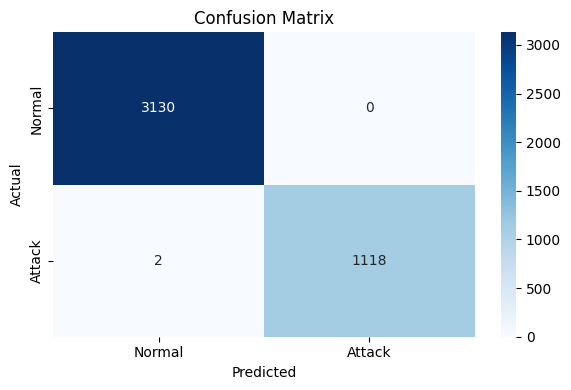

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Load and preprocess data
df = pd.read_csv("engineered_features.csv")
X = df.drop(columns=["window_start", "label"])
y = df["label"]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reattach for sequential sampling
X_df = pd.DataFrame(X_scaled, columns=X.columns)
X_df['window_start'] = pd.to_datetime(df['window_start'])
X_df['label'] = y.values
X_df.sort_values('window_start', inplace=True)

# Select every 10th window for testing to reduce overlap
test_idx = np.arange(0, len(X_df), 10)
train_idx = np.setdiff1d(np.arange(len(X_df)), test_idx)

train_df = X_df.iloc[train_idx]
test_df = X_df.iloc[test_idx]

X_train = train_df.drop(columns=['window_start', 'label']).values
y_train = train_df['label'].values
X_test = test_df.drop(columns=['window_start', 'label']).values
y_test = test_df['label'].values

# Compute class weights
weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: weights[0], 1: weights[1]}

# Define neural network model
model = Sequential([
    Dense(4, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(2, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, 
          class_weight=class_weights, callbacks=[early_stop], verbose=1)

# Save the model
model.save("binary_with_mitm.h5")
import joblib
joblib.dump(scaler, "scaler_with_mitm.save")


# Evaluate the model
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification report
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [138]:
print("Train label distribution:", np.bincount(y_train.astype(int)) / len(y_train))
print("Test label distribution:", np.bincount(y_test.astype(int)) / len(y_test))


Train label distribution: [0.73605229 0.26394771]
Test label distribution: [0.73647059 0.26352941]
